# Notebook 03 — Feature Engineering

## Objective
Turn every discharge cycle into one row of statistical features (mean, std, RMS, skewness, kurtosis, etc.) that can be used as input to a Random Forest.

## Why This Step Is Needed
A Random Forest needs a fixed-size input row per example. Each discharge cycle is a variable-length time series -- feature engineering summarizes it into a consistent set of numbers that still capture the shape and behavior of the signal.

## Workflow Position
```
01 Data Understanding -> 02 Preprocessing -> [YOU ARE HERE] 03 Feature Engineering
-> 04 Ground Truth Labels -> 05 Model Training (AHRF) -> 06 Model Comparison
-> 07 Explainability (SHAP) -> 08 Decision Engine & Summary
```


## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.core.config import BATTERY_IDS, FEATURE_DATA
from src.feature_engineering.extractor import build_feature_dataset, extract_features_from_cycle
from src.core.data_loader import load_processed_file, list_processed_files

plt.rcParams["figure.figsize"] = (10, 5)
BATTERY_ID = BATTERY_IDS[0]


## 2. Feature Extraction on One Cycle (Sanity Check)

Before running feature extraction on the whole dataset, extract features from a single cycle and inspect them, to confirm the logic produces sensible values.


In [3]:
sample_fname = list_processed_files(BATTERY_ID, "discharge")[0]
sample_df = load_processed_file(BATTERY_ID, "discharge", sample_fname)

sample_features = extract_features_from_cycle(sample_df)
pd.Series(sample_features)


Voltage_measured_mean      3.529829e+00
Voltage_measured_std       2.359571e-01
Voltage_measured_var       5.567574e-02
Voltage_measured_median    3.529903e+00
Voltage_measured_rms       3.537706e+00
                               ...     
Time_max                   3.690234e+03
Time_skew                  3.574107e-02
Time_kurtosis             -1.191403e+00
Time_peak_to_peak          3.690234e+03
Time_energy                8.709766e+08
Length: 66, dtype: float64

### Observation
Each raw column (e.g. `Voltage_measured`) should have produced 11 derived features (`_mean`, `_std`, `_var`, `_median`, `_rms`, `_min`, `_max`, `_skew`, `_kurtosis`, `_peak_to_peak`, `_energy`). Spot-check that `Voltage_measured_mean` looks like a plausible average voltage (roughly 3.0-4.0 V for these cells).


## 3. Build the Full Feature Dataset (Discharge Cycles)

Now run feature extraction across every discharge cycle for this battery, producing one row per cycle.


In [4]:
discharge_features = build_feature_dataset(BATTERY_ID, "discharge")

print("Shape:", discharge_features.shape)
discharge_features.head()


Shape: (168, 70)


,Voltage_measured_mean,Voltage_measured_std,Voltage_measured_var,Voltage_measured_median,Voltage_measured_rms,Voltage_measured_min,Voltage_measured_max,Voltage_measured_skew,Voltage_measured_kurtosis,Voltage_measured_peak_to_peak,...,Time_min,Time_max,Time_skew,Time_kurtosis,Time_peak_to_peak,Time_energy,File,Experiment,battery_id,cycle_index
0,3.529829,0.235957,0.055676,3.529903,3.537706,2.612467,4.191492,-0.507815,1.309881,1.579024,...,0.0,3690.234,0.035741,-1.191403,3690.234,8.709766e+08,05122.csv,discharge,B0005,1
1,3.537320,0.234765,0.055115,3.535737,3.545102,2.587209,4.189773,-0.550070,1.530856,1.602564,...,0.0,3672.344,0.035815,-1.191572,3672.344,8.580894e+08,05124.csv,discharge,B0005,2
2,3.543737,0.227525,0.051768,3.538223,3.551033,2.651917,4.188187,-0.439364,1.324421,1.536270,...,0.0,3651.641,0.034885,-1.191941,3651.641,8.447876e+08,05126.csv,discharge,B0005,3
3,3.543666,0.232744,0.054170,3.540233,3.551301,2.592948,4.188461,-0.547825,1.584145,1.595513,...,0.0,3631.563,0.034515,-1.192722,3631.563,8.316074e+08,05128.csv,discharge,B0005,4
4,3.542343,0.236689,0.056021,3.540603,3.550242,2.547420,4.188299,-0.623350,1.781325,1.640879,...,0.0,3629.172,0.034242,-1.192454,3629.172,8.307275e+08,05130.csv,discharge,B0005,5


In [5]:
print("Any missing values?", discharge_features.isna().sum().sum())
print("Number of feature columns:", discharge_features.shape[1] - 4)  # minus File/Experiment/battery_id/cycle_index


Any missing values? 0
Number of feature columns: 66


### Observation
There should be zero missing values (Notebook 02's cleaning step should have already handled gaps). The number of feature columns should equal `11 x (number of signal columns present in your data)`.


## 4. Feature Distributions

A quick look at whether the engineered features have reasonable, non-degenerate distributions (not all-zero, not all-identical).


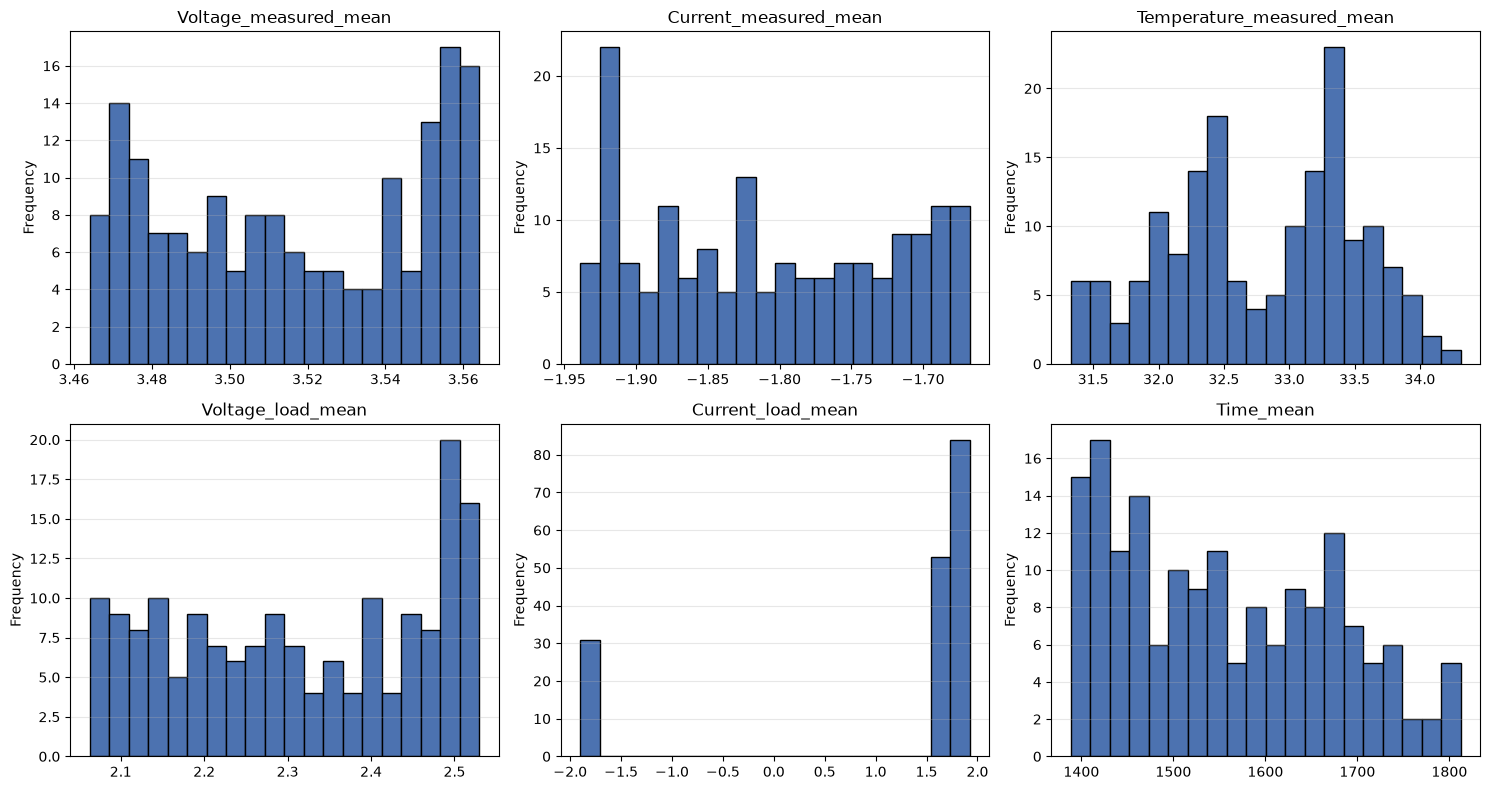

In [6]:
feature_cols = [c for c in discharge_features.columns
                if c not in ["File", "Experiment", "battery_id", "cycle_index"]]

sample_features_to_plot = [c for c in feature_cols if c.endswith("_mean")][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), sample_features_to_plot):
    discharge_features[col].plot(kind="hist", bins=20, ax=ax, color="#4C72B0", edgecolor="black")
    ax.set_title(col)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


### Observation
Watch for any feature that's a flat spike at a single value (e.g. all zeros) -- that would indicate the underlying raw column was missing or constant for every cycle, and that feature should probably be dropped before modeling.


## 5. Feature Trend Across Cycle Life

Since we're predicting battery degradation, several features should show a clear trend as cycle_index increases (early life vs. late life). This is a good sign the features actually carry degradation information.


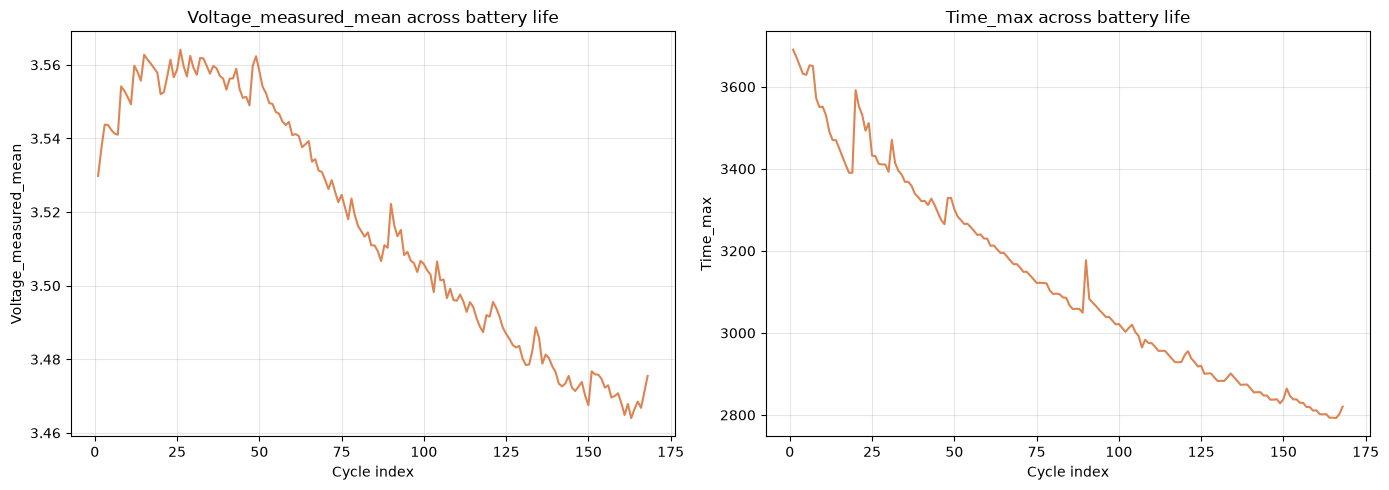

In [7]:
trend_candidates = [c for c in feature_cols if "Voltage_measured_mean" in c or "Time_max" in c]

fig, axes = plt.subplots(1, len(trend_candidates), figsize=(7 * len(trend_candidates), 5))
if len(trend_candidates) == 1:
    axes = [axes]

for ax, col in zip(axes, trend_candidates):
    ax.plot(discharge_features["cycle_index"], discharge_features[col], color="#DD8452")
    ax.set_title(f"{col} across battery life")
    ax.set_xlabel("Cycle index")
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Observation
`Voltage_measured_mean` should trend downward over the battery's life (aging reduces average voltage during discharge), and `Time_max` (total discharge duration) should also trend downward (a degraded battery empties faster). If these trends are visible, the raw features are informative for the modeling stage.


## 6. Correlation Heatmap

Many of these 11-per-signal statistics will be highly correlated with each other (e.g. `_min` and `_mean` for a signal that barely varies). This motivates the feature selection step we'll do with SHAP later (Notebook 05/06) -- we don't need to manually prune here, just be aware of the redundancy.


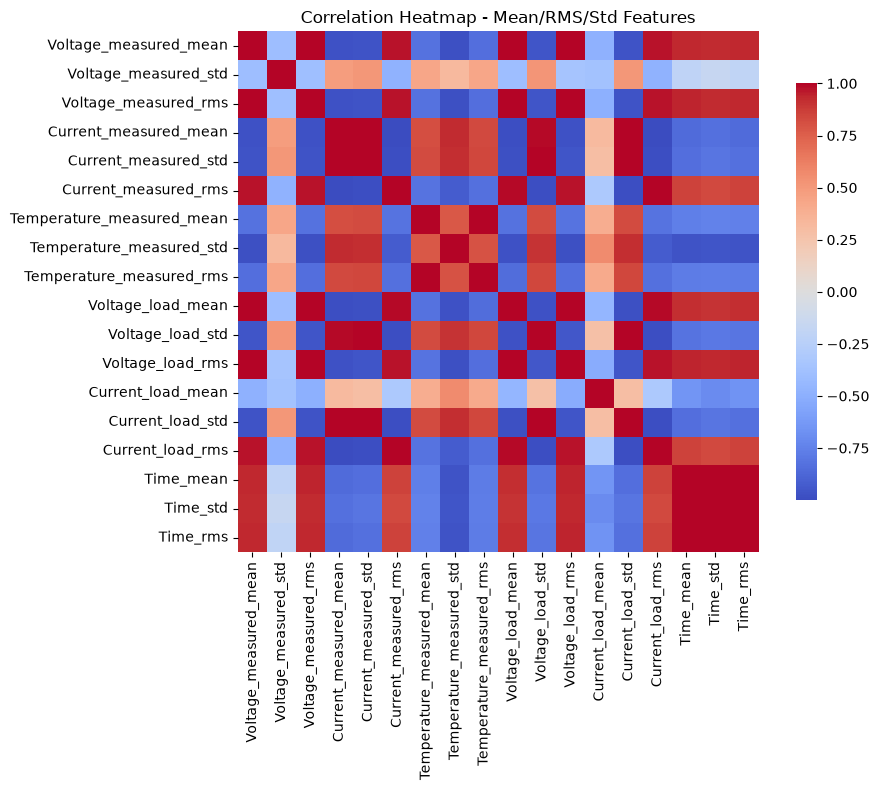

In [8]:
mean_features = [c for c in feature_cols if c.endswith("_mean") or c.endswith("_rms") or c.endswith("_std")]

corr = discharge_features[mean_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap - Mean/RMS/Std Features")
plt.tight_layout()
plt.show()


### Observation
Expect strong correlation clusters (e.g. all statistics derived from the same signal tend to move together). This confirms the dataset has redundant information -- exactly what SHAP-based feature selection in Notebook 05 will help address, rather than us manually guessing which features to drop.


## 7. Save Feature Dataset


In [9]:
output_path = FEATURE_DATA / "discharge_features.csv"
discharge_features.to_csv(output_path, index=False)
print("Saved to:", output_path)


Saved to: C:\BE PROJECT\SBMS_PROJECT\dataset\features\discharge_features.csv


## Results Summary

| Item | Value |
|---|---|
| Number of discharge cycles processed | See Section 3 shape |
| Number of engineered features | See Section 3 |
| Missing values in final dataset | 0 |
| Clear degradation trend visible | See Section 5 |

## Conclusion
Every discharge cycle has been converted into a row of ~60-70 statistical features, saved to `dataset/features/discharge_features.csv`. Voltage- and duration-related features show a visible degradation trend across cycle life, confirming they carry useful signal for the SOC/SOH/RUL models.

## Next Steps
Notebook 04 will generate the actual target labels (SOC, SOH, RUL) and merge them with this feature dataset, using the real battery metadata (Capacity values).
